### Importaciones y configuración

In [52]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from joblib import Parallel, delayed
from models_forecasting import procesar_grupo

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# ── Parámetros editables ──────────────────────────────────────────────
RUTA = "/home/jovyan/work"
ARCHIVO_DATOS   = '/data/data_historico.csv'
ARCHIVO_SALIDA  = '/data/data_predicciones.csv'
PERIODOS_FUTURO = 10   # 5 años × 2 semestres
N_JOBS          = -1   # -1 = todos los núcleos disponibles

### Carga de datos

In [53]:
df = pd.read_csv(RUTA + ARCHIVO_DATOS)
df['fecha'] = pd.to_datetime(df['fecha'])

print(f'Filas totales   : {len(df):,}')
print(f'Columnas        : {list(df.columns)}')
print(f'Rango de fechas : {df["fecha"].min().date()} → {df["fecha"].max().date()}')
print()
df.head(6)

Filas totales   : 553,745
Columnas        : ['codigo_institucion', 'codigo_programa', 'codigo_municipio', 'codigo_genero', 'fecha', 'matriculados']
Rango de fechas : 2014-01-01 → 2024-07-01



,codigo_institucion,codigo_programa,codigo_municipio,codigo_genero,fecha,matriculados
0,1101,1,11001,1,2014-01-01,446
1,1101,1,11001,1,2014-07-01,446
2,1101,1,11001,1,2015-01-01,438
3,1101,1,11001,1,2015-07-01,448
4,1101,1,11001,1,2016-01-01,410
5,1101,1,11001,1,2016-07-01,428


In [54]:
# Resumen de la agrupación
COLS_GRUPO = ['codigo_institucion', 'codigo_programa', 'codigo_municipio', 'codigo_genero']
grupos     = df.groupby(COLS_GRUPO).size()

print(f'Instituciones únicas : {df["codigo_institucion"].nunique()}')
print(f'Programas únicos     : {df["codigo_programa"].nunique()}')
print(f'Municipios únicos    : {df["codigo_municipio"].nunique()}')
print(f'Géneros únicos       : {df["codigo_genero"].nunique()}')
print(f'────────────────────────────────────')
print(f'Total de grupos      : {len(grupos):,}')
print(f'Puntos por grupo     : mín={grupos.min()}  máx={grupos.max()}  prom={grupos.mean():.1f}')

Instituciones únicas : 316
Programas únicos     : 11017
Municipios únicos    : 290
Géneros únicos       : 2
────────────────────────────────────
Total de grupos      : 31,147
Puntos por grupo     : mín=11  máx=22  prom=17.8


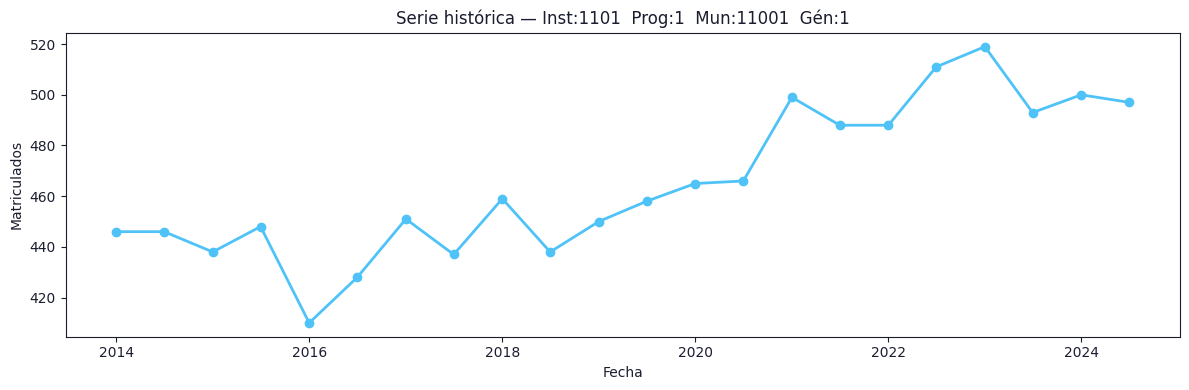

In [62]:
# Visualizar la serie del primer grupo como ejemplo
primer_grupo = df.groupby(COLS_GRUPO).first().index[0]
mask = (
    (df['codigo_institucion'] == primer_grupo[0]) &
    (df['codigo_programa']    == primer_grupo[1]) &
    (df['codigo_municipio']   == primer_grupo[2]) &
    (df['codigo_genero']      == primer_grupo[3])
)
serie_ej = df[mask].sort_values('fecha')

plt.figure(figsize=(12, 4), facecolor='#ffffff')
ax = plt.gca(); ax.set_facecolor('#ffffff')
ax.plot(serie_ej['fecha'], serie_ej['matriculados'],
        'o-', color='#4FC3F7', lw=2, ms=6)
ax.set_title(
    f'Serie histórica — Inst:{primer_grupo[0]}  Prog:{primer_grupo[1]}  '
    f'Mun:{primer_grupo[2]}  Gén:{primer_grupo[3]}',
    color='#1a1d2e', fontsize=12
)
 
for spine in ax.spines.values():
    spine.set_edgecolor('#1a1d2e')
    spine.set_linewidth(0.8)

ax.set_xlabel('Fecha', color='#1a1d2e')
ax.set_ylabel('Matriculados', color='#1a1d2e')
ax.tick_params(colors='#1a1d2e')
plt.tight_layout()
plt.savefig(RUTA + '/images/serie_primer_gurpo.png', dpi=150, bbox_inches='tight')
plt.show()

### Ejecución

In [56]:
grupos_lista = list(df.groupby(COLS_GRUPO))
total_grupos = len(grupos_lista)

print(f'Total de grupos a procesar : {total_grupos:,}')

todos_resultados = Parallel(n_jobs=N_JOBS, verbose=5, prefer='threads')(
    delayed(procesar_grupo)(args) for args in grupos_lista
)

print(f'\nProcesamiento completo — {len(todos_resultados):,} grupos')

Total de grupos a procesar : 31,147


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 284 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 446 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 644 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 878 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 1148 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 1454 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 1796 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 2174 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 2588 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 3038 tasks      | elapsed:    6.6s
[Parallel(n_jobs=-1)]: Done 3524 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done 4046 tasks      


Procesamiento completo — 31,147 grupos


[Parallel(n_jobs=-1)]: Done 31147 out of 31147 | elapsed:  1.1min finished


### Métricas

| Métrica | Qué mide | Interpretación |
|---------|----------|----------------|
| **MAE** | Error absoluto promedio | En unidades de matriculados |
| **RMSE** | Raíz del error cuadrático | Penaliza más los errores grandes |
| **MAPE** | Error porcentual absoluto | Independiente de la escala |

**Menor es mejor** en las tres métricas.

In [57]:
# Recolectar métricas grupo a grupo
sarima_maes,  prophet_maes  = [], []
sarima_mses,  prophet_mses  = [], []
sarima_mapes, prophet_mapes = [], []
sarima_gana,  prophet_gana  = 0, 0

for r in todos_resultados:
    sarima_maes .append(r['metricas']['sarima']['MAE'])
    sarima_mses .append(r['metricas']['sarima']['MSE'])
    sarima_mapes.append(r['metricas']['sarima']['MAPE'])
    prophet_maes .append(r['metricas']['prophet']['MAE'])
    prophet_mses .append(r['metricas']['prophet']['MSE'])
    prophet_mapes.append(r['metricas']['prophet']['MAPE'])
    if r['mejor_modelo'] == 'SARIMA':
        sarima_gana  += 1
    else:
        prophet_gana += 1

tabla = pd.DataFrame({
    'Modelo'           : ['SARIMA', 'PROPHET'],
    'MAE (promedio)'   : [np.nanmean(sarima_maes),              np.nanmean(prophet_maes)],
    'RMSE (promedio)'  : [np.sqrt(np.nanmean(sarima_mses)),     np.sqrt(np.nanmean(prophet_mses))],
    'MAPE % (promedio)': [np.nanmean(sarima_mapes),             np.nanmean(prophet_mapes)],
    'Grupos ganados'   : [sarima_gana,                          prophet_gana],
    '% victorias'      : [f'{sarima_gana/total_grupos*100:.1f}%', f'{prophet_gana/total_grupos*100:.1f}%'],
})

modelo_ganador = 'SARIMA' if sarima_gana >= prophet_gana else 'PROPHET'
print(f'Modelo con mejor desempeño: {modelo_ganador}\n')
tabla.round(3)

Modelo con mejor desempeño: SARIMA



,Modelo,MAE (promedio),RMSE (promedio),MAPE % (promedio),Grupos ganados,% victorias
0,SARIMA,26.893,153.846,157.481,21642,69.5%
1,PROPHET,29.992,163.701,175.141,9505,30.5%


### Gráfica comparativa

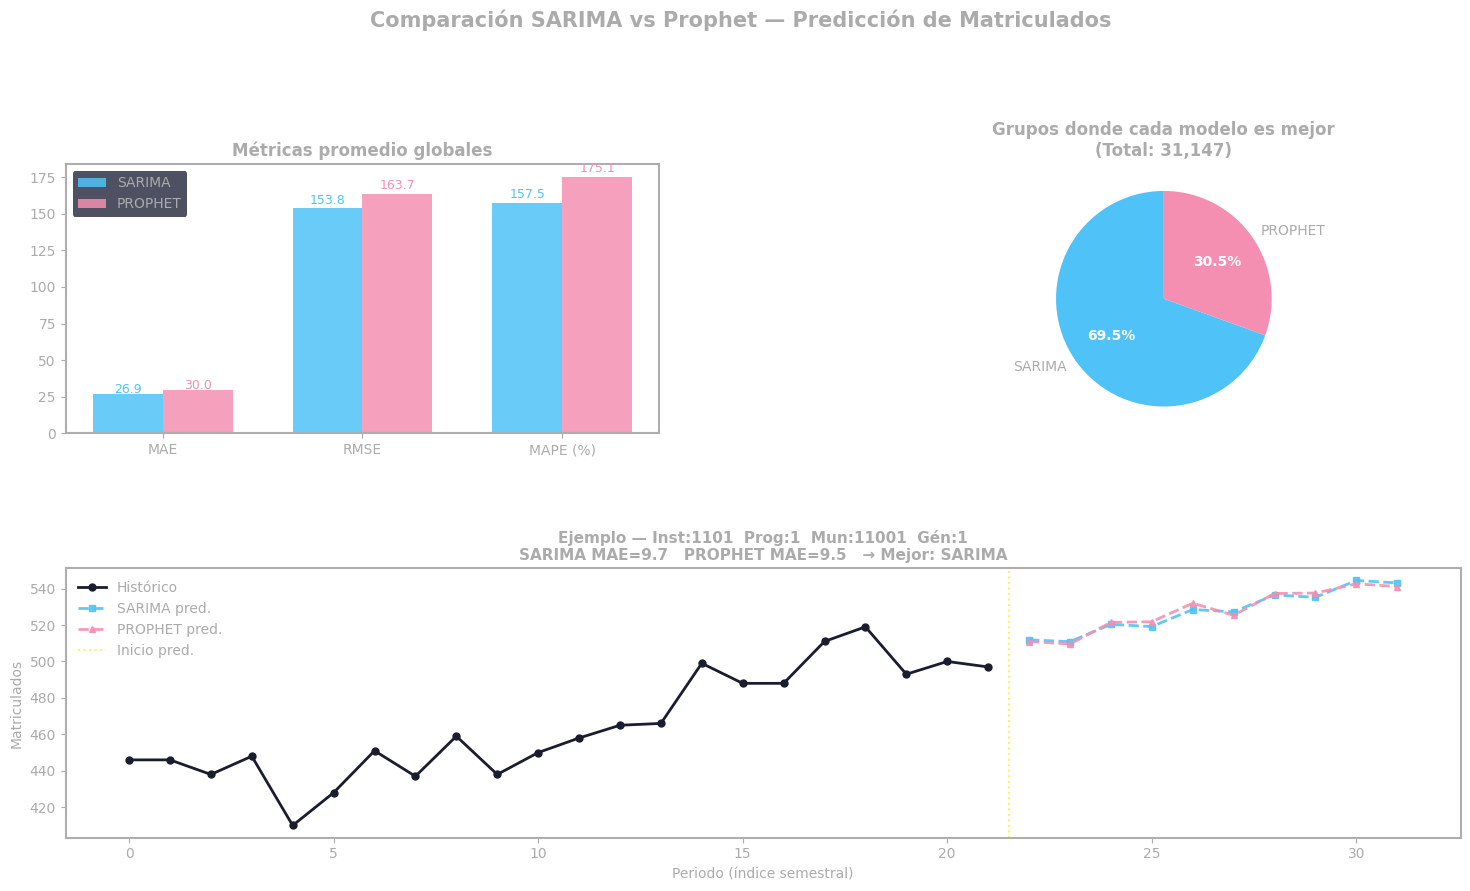

In [78]:
C_SARIMA  = '#4FC3F7'
C_PROPHET = '#F48FB1'
C_BG      = '#ffffff'
C_FIG     = '#ffffff'
C_TEXT    = '#ABABAB'

# ── Helper: aplica borde negro a cualquier eje ─────────────
def borde_negro(ax, lw=1.5):
    for spine in ax.spines.values():
        spine.set_edgecolor('#AEAEAE')
        spine.set_linewidth(lw)
# ───────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 14), facecolor=C_FIG)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

# Barras de métricas globales
ax3 = fig.add_subplot(gs[0, 0]); ax3.set_facecolor(C_BG)
etiquetas = ['MAE', 'RMSE', 'MAPE (%)']
vals_s    = [np.nanmean(sarima_maes),  np.sqrt(np.nanmean(sarima_mses)),  np.nanmean(sarima_mapes)]
vals_p    = [np.nanmean(prophet_maes), np.sqrt(np.nanmean(prophet_mses)), np.nanmean(prophet_mapes)]
x, w      = np.arange(3), 0.35
bars_s    = ax3.bar(x - w/2, vals_s, w, color=C_SARIMA,  alpha=0.85, label='SARIMA')
bars_p    = ax3.bar(x + w/2, vals_p, w, color=C_PROPHET, alpha=0.85, label='PROPHET')
for b in bars_s:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() * 1.02,
             f'{b.get_height():.1f}', ha='center', color=C_SARIMA, fontsize=9)
for b in bars_p:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() * 1.02,
             f'{b.get_height():.1f}', ha='center', color=C_PROPHET, fontsize=9)
ax3.set_xticks(x); ax3.set_xticklabels(etiquetas, color=C_TEXT)
ax3.set_title('Métricas promedio globales', color=C_TEXT, fontsize=12, fontweight='bold')
ax3.tick_params(colors=C_TEXT)
ax3.legend(facecolor='#22253a', edgecolor='none', labelcolor=C_TEXT)
borde_negro(ax3)  # ← borde negro

# Torta de victorias
ax4 = fig.add_subplot(gs[0, 1]); ax4.set_facecolor(C_BG)
wedges, texts, autotexts = ax4.pie(
    [sarima_gana, prophet_gana],
    labels=['SARIMA', 'PROPHET'],
    colors=[C_SARIMA, C_PROPHET],
    autopct='%1.1f%%', startangle=90,
    textprops={'color': C_TEXT}
)
for a in autotexts:
    a.set_color('#ffffff'); a.set_fontweight('bold')
ax4.set_title(f'Grupos donde cada modelo es mejor\n(Total: {total_grupos:,})',
              color=C_TEXT, fontsize=12, fontweight='bold')
borde_negro(ax4)  # ← borde negro

# Ejemplo de predicción
ax5 = fig.add_subplot(gs[1, :]); ax5.set_facecolor(C_BG)
muestra = sorted(todos_resultados, key=lambda r: len(r['serie']), reverse=True)[0]
k, ser, n_s = muestra['clave'], muestra['serie'], len(muestra['serie'])
ax5.plot(range(n_s), ser,
         'o-', color='#1a1d2e', lw=2, ms=5, label='Histórico', zorder=3)
ax5.plot(range(n_s, n_s + PERIODOS_FUTURO), muestra['pred_sarima'],
         's--', color=C_SARIMA, lw=2, ms=5, label='SARIMA pred.', alpha=0.9)
ax5.plot(range(n_s, n_s + PERIODOS_FUTURO), muestra['pred_prophet'],
         '^--', color=C_PROPHET, lw=2, ms=5, label='PROPHET pred.', alpha=0.9)
ax5.axvline(n_s - 0.5, color='#ffeb3b', ls=':', lw=1.5, alpha=0.8, label='Inicio pred.')
ax5.set_title(
    f'Ejemplo — Inst:{k[0]}  Prog:{k[1]}  Mun:{k[2]}  Gén:{k[3]}\n'
    f'SARIMA MAE={muestra["metricas"]["sarima"]["MAE"]:.1f}   '
    f'PROPHET MAE={muestra["metricas"]["prophet"]["MAE"]:.1f}   '
    f'→ Mejor: {muestra["mejor_modelo"]}',
    color=C_TEXT, fontsize=11, fontweight='bold'
)
ax5.set_xlabel('Periodo (índice semestral)', color=C_TEXT)
ax5.set_ylabel('Matriculados', color=C_TEXT)
ax5.tick_params(colors=C_TEXT)
ax5.legend(facecolor='#ffffff', edgecolor='none', labelcolor=C_TEXT)
borde_negro(ax5)

fig.suptitle('Comparación SARIMA vs Prophet — Predicción de Matriculados',
             color=C_TEXT, fontsize=15, fontweight='bold', y=0.99)
plt.savefig(RUTA + '/images/comparacion_modelos.png', dpi=150, bbox_inches='tight', facecolor=C_FIG)
plt.show()

### Guardar predicciones

El archivo de salida incluye las columnas necesarias para Power BI:

| Columna | Descripción |
|---------|-------------|
| `codigo_*` | Claves de agrupación para filtros y segmentadores |
| `fecha` | Fecha del semestre predicho (YYYY-MM-DD) |
| `año` / `semestre` | Para jerarquía de fechas en Power BI |
| `matriculados_prediccion` | Valor predicho redondeado |

In [59]:
filas = []

for r in todos_resultados:
    clave  = r['clave']
    modelo = r['mejor_modelo']
    preds  = r['mejor_pred']
    mets   = r['metricas'][modelo.lower()]

    for fd, val in zip(r['fechas_futuras'], preds):
        filas.append({
            'codigo_institucion'     : clave[0],
            'codigo_programa'        : clave[1],
            'codigo_municipio'       : clave[2],
            'codigo_genero'          : clave[3],
            'fecha'                  : fd.strftime('%Y-%m-%d'),
            'año'                    : fd.year,
            'semestre'               : 1 if fd.month == 1 else 2,
            'matriculados'           : round(float(val))
        })

pred_df = pd.DataFrame(filas)
pred_df.to_csv(RUTA + ARCHIVO_SALIDA, index=False)

print(f'   Archivo guardado: {ARCHIVO_SALIDA}')
print(f'   Filas totales   : {len(pred_df):,}')
print(f'   Columnas        : {list(pred_df.columns)}')
print()
pred_df.head(6)

   Archivo guardado: /data/data_predicciones.csv
   Filas totales   : 311,470
   Columnas        : ['codigo_institucion', 'codigo_programa', 'codigo_municipio', 'codigo_genero', 'fecha', 'año', 'semestre', 'matriculados']



,codigo_institucion,codigo_programa,codigo_municipio,codigo_genero,fecha,año,semestre,matriculados
0,1101,1,11001,1,2025-01-01,2025,1,512
1,1101,1,11001,1,2025-07-01,2025,2,511
2,1101,1,11001,1,2026-01-01,2026,1,520
3,1101,1,11001,1,2026-07-01,2026,2,519
4,1101,1,11001,1,2027-01-01,2027,1,529
5,1101,1,11001,1,2027-07-01,2027,2,527


### Resumen

In [60]:
print('-' * 58)
print('  RESUMEN')
print('-' * 58)
print(tabla.round(3).to_string(index=False))
print()
print(f'  Modelo ocn mejor desempeño : {modelo_ganador}')
print(f'  Archivo de salida          : {ARCHIVO_SALIDA}')
print(f'  Predicciones generadas     : {len(pred_df):,} filas')
print(f'  Ventana                    : {PERIODOS_FUTURO // 2} años ({PERIODOS_FUTURO} semestres)')


----------------------------------------------------------
  RESUMEN
----------------------------------------------------------
 Modelo  MAE (promedio)  RMSE (promedio)  MAPE % (promedio)  Grupos ganados % victorias
 SARIMA          26.893          153.846            157.481           21642       69.5%
PROPHET          29.992          163.701            175.141            9505       30.5%

  Modelo ocn mejor desempeño : SARIMA
  Archivo de salida          : /data/data_predicciones.csv
  Predicciones generadas     : 311,470 filas
  Ventana                    : 5 años (10 semestres)
